In [97]:
import shap 
import xgboost 
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as pyplot
import matplotlib
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [66]:
data = pd.read_csv("/Users/sorenbasnet/Documents/Github/STAT_443_FINAL_PROJECT/data/data_patient_file_cna_rai/patient_file_cna_rai.txt", 
                   sep=r'\s+',index_col=0)
data.head()

,PATIENT_ID,ONCOTREE_CODE,DISEASE_TYPE,NORMAL_MEAN_COVERAGE,TUMOR_MEAN_COVERAGE,TUMOR_SAMPLE_PURITY,TUMOR_SAMPLE_PLOIDY,CANCER_TYPE,CANCER_TYPE_DETAILED,SOMATIC_STATUS,...,6q_status,8p_status,8q_status,tri12_status,RAI_AT_DIAGNOSIS,TREATMENT_STATUS_AT_SAMPLING,RAI_AT_SAMPLING,FIRST_TREATMENT_AFTER_SAMPLING,surv_5yrs,death_5yr
SAMPLE_ID,,,,,,,,,,,,,,,,,,,,,
CRC_0001,P_CRC_0001,CLLSLL,CLL,63.0,79.7,0.92,2.00,Mature__B_Cell__Neoplasms,Chronic__Lymphocytic__Leukemia_Small__Lymphocy...,Matched,...,Unchanged,Unchanged,Gain,Unchanged,0.0,Untreated,0.0,Chemo__+__Ab,60.00,0.0
CRC_0002,P_CRC_0002,CLLSLL,CLL,70.1,135.5,0.94,2.03,Mature__B_Cell__Neoplasms,Chronic__Lymphocytic__Leukemia_Small__Lymphocy...,Matched,...,Unchanged,Unchanged,Unchanged,Unchanged,0.0,Untreated,0.0,Chemo__+__Ab,60.00,0.0
CRC_0003,P_CRC_0003,CLLSLL,CLL,77.2,141.1,0.83,2.05,Mature__B_Cell__Neoplasms,Chronic__Lymphocytic__Leukemia_Small__Lymphocy...,Matched,...,Unchanged,Unchanged,Unchanged,Gain,0.0,Untreated,0.0,Chemo__+__Ab,51.25,1.0
CRC_0004,P_CRC_0004,CLLSLL,CLL,60.2,146.0,0.92,2.00,Mature__B_Cell__Neoplasms,Chronic__Lymphocytic__Leukemia_Small__Lymphocy...,Matched,...,Unchanged,Unchanged,Unchanged,Unchanged,0.0,Untreated,0.0,Chemo__+__Ab,60.00,0.0
CRC_0005,P_CRC_0005,CLLSLL,CLL,106.5,82.1,0.87,2.05,Mature__B_Cell__Neoplasms,Chronic__Lymphocytic__Leukemia_Small__Lymphocy...,Matched,...,Unchanged,Unchanged,Unchanged,Gain,0.0,Untreated,0.0,Chemo__+__Ab,60.00,0.0


In [67]:
data.columns

Index(['PATIENT_ID', 'ONCOTREE_CODE', 'DISEASE_TYPE', 'NORMAL_MEAN_COVERAGE',
       'TUMOR_MEAN_COVERAGE', 'TUMOR_SAMPLE_PURITY', 'TUMOR_SAMPLE_PLOIDY',
       'CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'SOMATIC_STATUS', 'CLL_EPITYPE',
       'TUMOR_MOLECULAR_SUBTYPE', 'SEQUENCING_PLATFORM', 'RNA_SEQUENCING',
       'RRBS', 'ARRAY450K', 'M.CLL_WES', 'U.CLL_WES', 'EC_DISCOVERY',
       'EC_EXTENSION', 'IGLV3_21_R110', 'U1_STATUS', 'TMB_NONSYNONYMOUS',
       'AGE', 'AGE_SAMPLING', 'SEX', 'OS_STATUS', 'OS_MONTHS', 'DEATH_DAYS',
       'COHORT', 'IGHV_MUTATION_STATUS', 'IGHV_IDENTITY_PERCENTAGE',
       'TREATMENT_STATUS', 'PRIOR_TREATMENT_CATEGORY',
       'TREATMENT_AFTER_SAMPLING', 'EXPRESSION_CLUSTER', 'FFS_STATUS',
       'FFS_MONTHS', '11q_status', '17p_status', '17q_status', '18p_status',
       '19q_status', '20p_status', '2p_status', '4p_status', '6q_status',
       '8p_status', '8q_status', 'tri12_status', 'RAI_AT_DIAGNOSIS',
       'TREATMENT_STATUS_AT_SAMPLING', 'RAI_AT_SAMPLING'

In [68]:
data = data.dropna(subset=["death_5yr"])

In [89]:
#data = data.dropna(subset=["death_5yr"])
X = data.drop(columns=["PATIENT_ID", "ONCOTREE_CODE", 
                          "DISEASE_TYPE", "OS_STATUS", "OS_MONTHS", 
                          "DEATH_DAYS","surv_5yrs", "death_5yr", "FFS_STATUS", 
                          "FFS_MONTHS"])

y = data["death_5yr"]


In [90]:
# This automatically generated dummies for categorical data 
X = pd.get_dummies(X)

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X,y)

In [92]:
y_train.isna().sum()

np.int64(0)

In [93]:
# train model 
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train) 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.83      0.99      0.90       208
         1.0       0.40      0.05      0.08        44

    accuracy                           0.82       252
   macro avg       0.61      0.52      0.49       252
weighted avg       0.75      0.82      0.76       252

--- Confusion Matrix ---


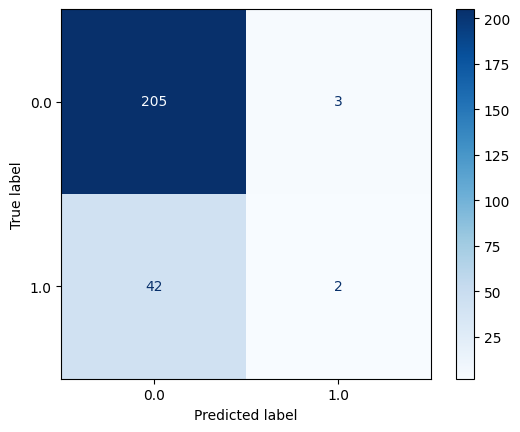

In [100]:
# Predict 
y_pred = model.predict(X_test)

# 2. Print text report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 3. Visualize the Confusion Matrix
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.show()

In [94]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

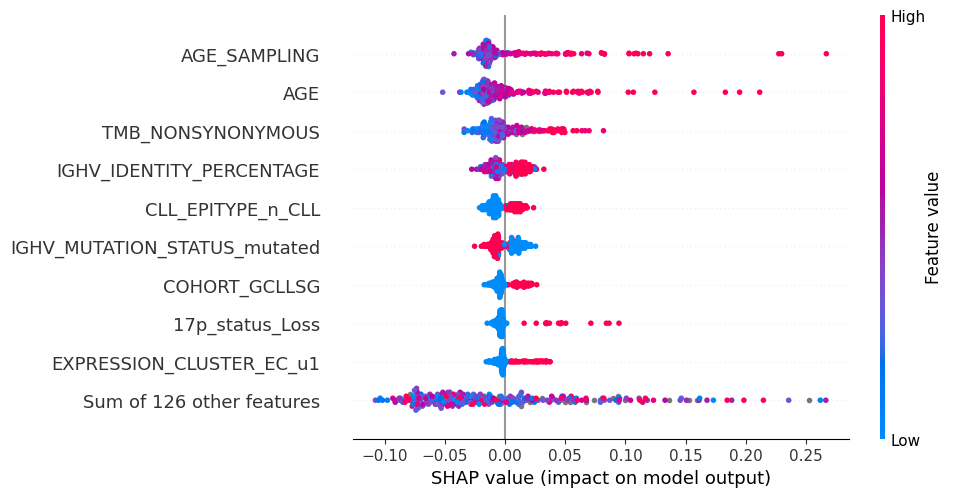

In [95]:
#2. Explain the model's predictions 
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

#3.Visualize 
# This shows the distribution of impacts 
# for each feature 
shap.plots.beeswarm(shap_values[:,:,1])

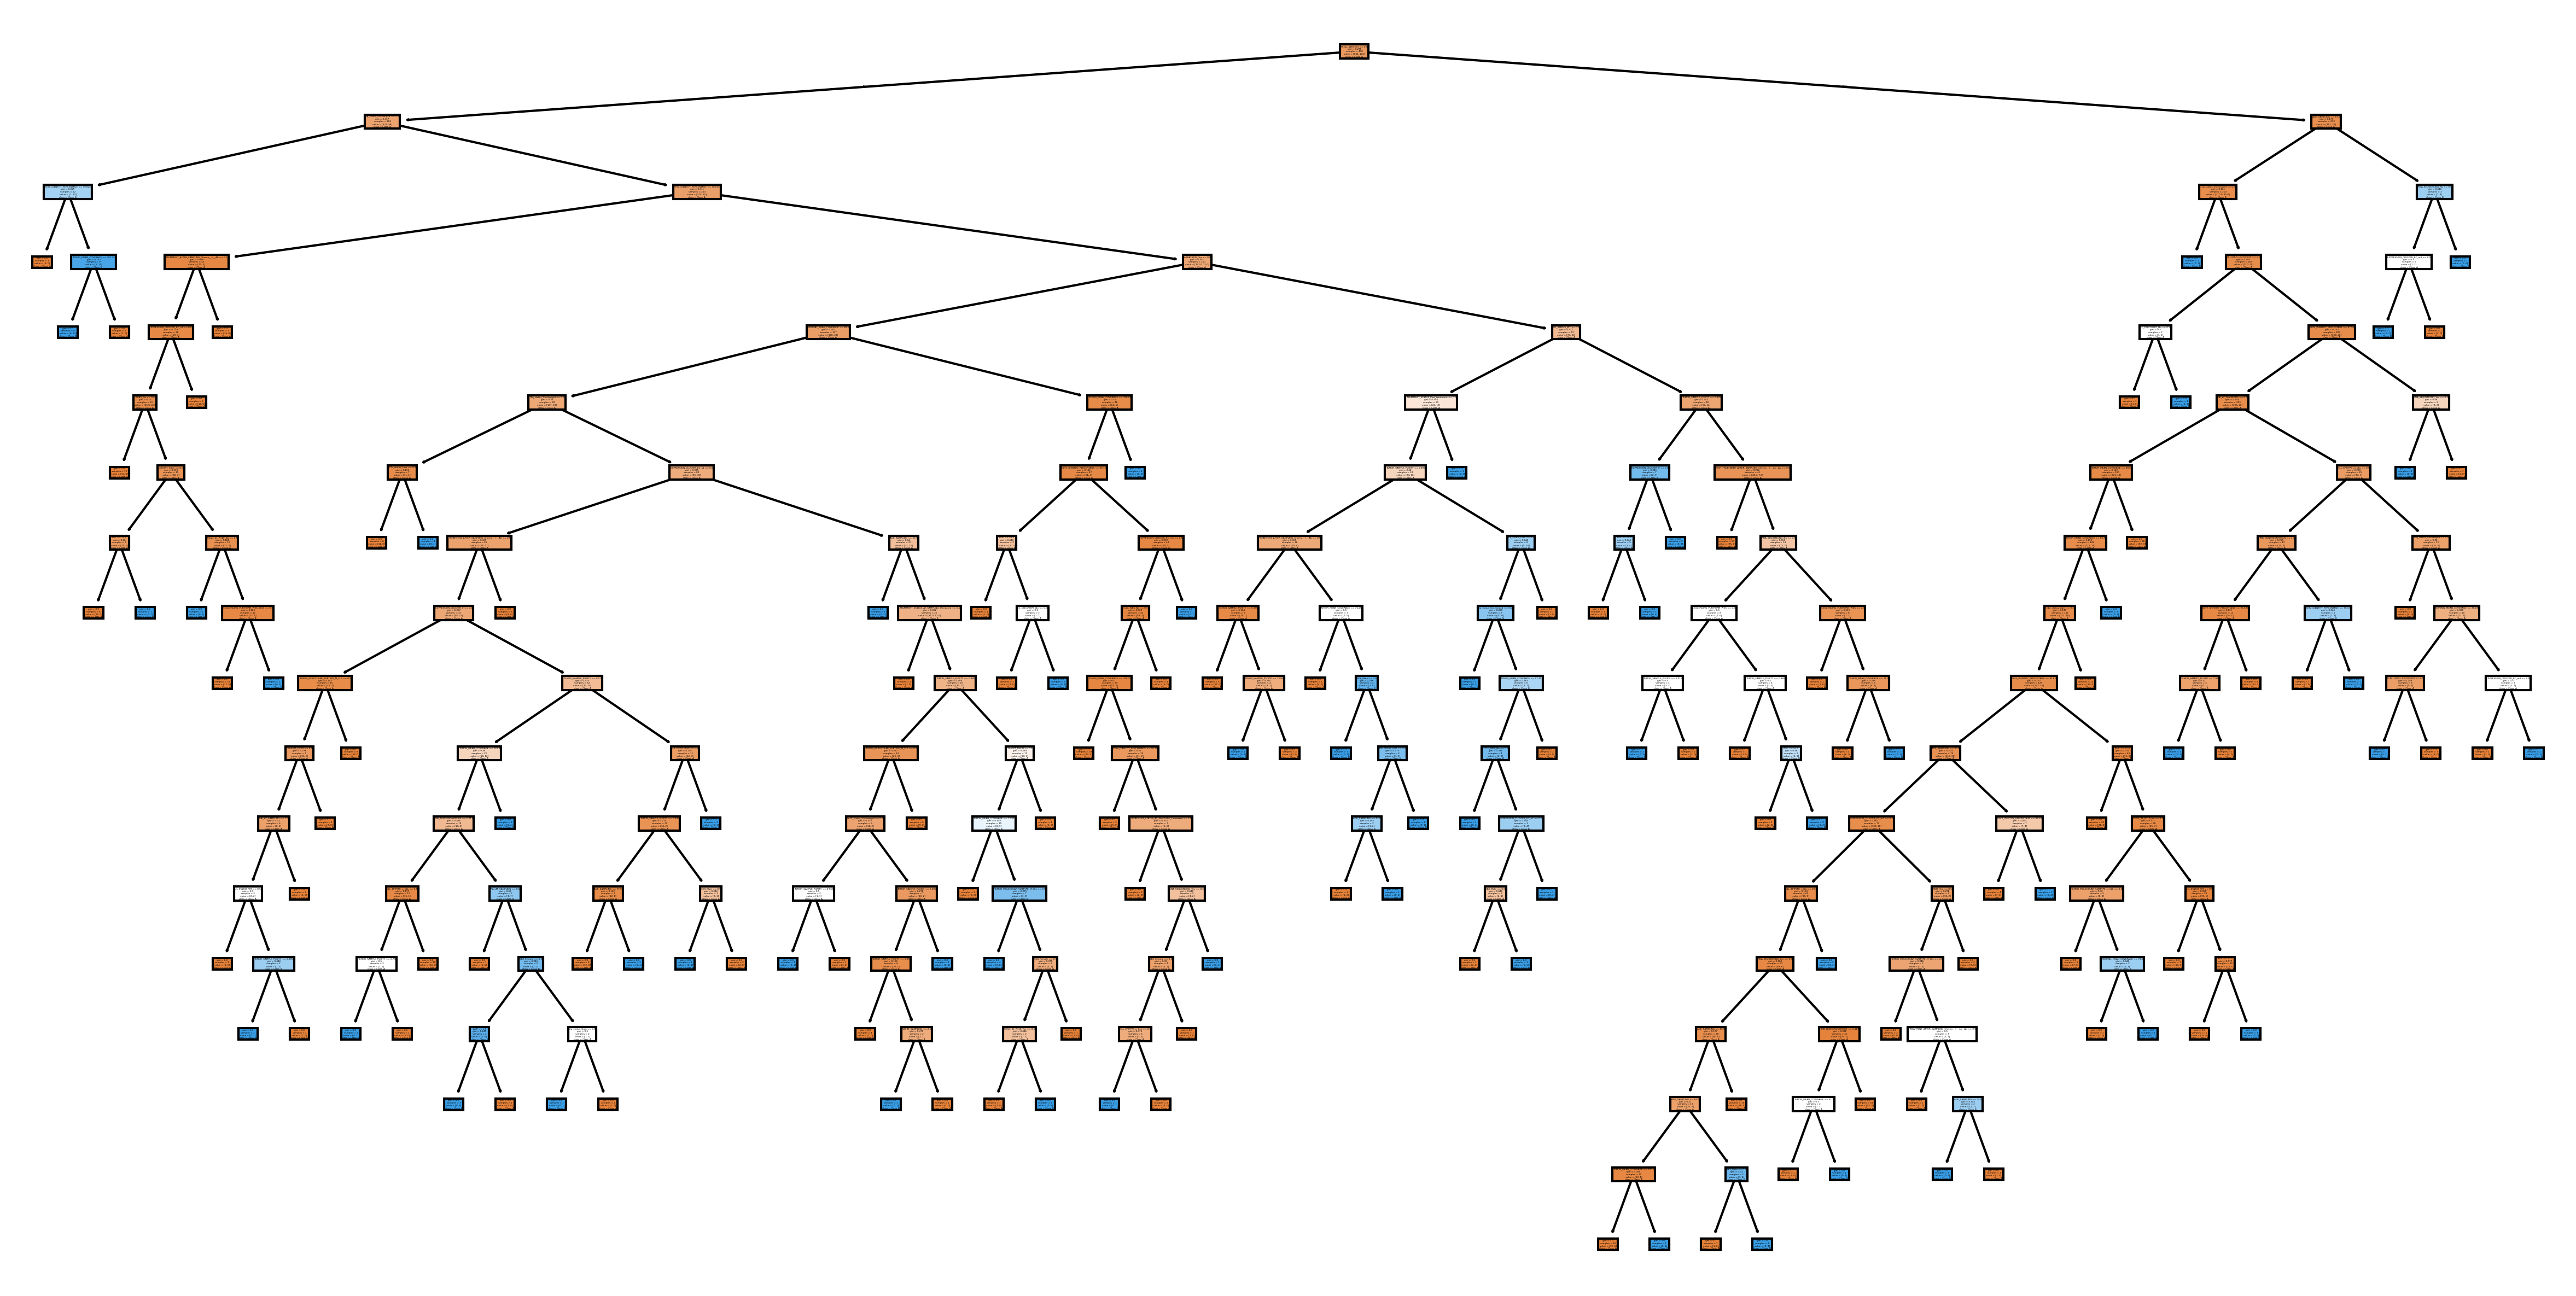

In [96]:
# visualize the first tree in the forest plot 
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt 

plt.figure(figsize=(20,10), dpi=300)
plot_tree(model.estimators_[0], 
          feature_names=X.columns, 
          class_names=['Class_A', 'Class_B'], 
          filled=True)
plt.show()
